# Life Expectancy and Economic Indicators Analysis

## Data Science Process
 
This analysis follows a structured data science workflow:
 
- Gather: Data is collected from World Development Indicators
- Assess: Dataset structure and missing values are explored
- Clean: Data is reshaped and missing values handled
- Analyze: Relationships between variables are explored
- Visualize: Graphs are used to understand patterns
- Model: Linear regression model is built
- Evaluate: Model performance is assessed

## Dataset: World Development Indicators
 
This project explores the relationship between economic indicators and life expectancy using data from the World Development Indicators dataset.

## Business Questions
 
1. What is the distribution of life expectancy?
2. Is GDP per capita related to life expectancy?
3. Does healthcare spending influence life expectancy?
4. Can economic indicators predict life expectancy?

Import Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

Load Data

In [13]:
 
df = pd.read_excel("P_Data_Extract_From_World_Development_Indicators.xlsx") 
df.head()


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.702,61.25,61.735,62.188,62.26,62.27,62.646,62.406,62.443,62.941,61.454,60.417,65.617,66.035
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,560.621505,606.694676,651.417134,637.087099,625.054942,565.56973,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,8.569672,8.561908,7.897169,8.805964,9.528878,10.105348,11.81859,12.620817,14.208419,14.83132,15.533614,21.508444,23.088169,14.985763
3,Afghanistan,AFG,"School enrollment, primary (% gross)",SE.PRM.ENRR,103.485603,101.542084,106.575317,107.942841,109.829453,106.773552,106.784042,106.543541,107.68766,109.07531,..,..,..,..
4,Afghanistan,AFG,People using safely managed drinking water ser...,SH.H2O.SMDW.ZS,19.224722,20.059192,20.89308,21.72638,22.559089,23.391308,24.222923,25.055177,25.888213,26.721855,27.555934,28.39068,29.225823,29.907448


In [15]:
df_filtered = df[df["Series Name"].isin([
    "Life expectancy at birth, total (years)",
    "GDP per capita (current US$)",
    "Current health expenditure (% of GDP)"
])]
 
df_filtered.head()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.702,61.25,61.735,62.188,62.26,62.27,62.646,62.406,62.443,62.941,61.454,60.417,65.617,66.035
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,560.621505,606.694676,651.417134,637.087099,625.054942,565.56973,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,8.569672,8.561908,7.897169,8.805964,9.528878,10.105348,11.81859,12.620817,14.208419,14.83132,15.533614,21.508444,23.088169,14.985763
5,Albania,ALB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,78.414,78.303,78.084,77.995,78.029,78.358,78.643,78.9,79.238,79.467,77.824,76.844,78.769,79.602
6,Albania,ALB,GDP per capita (current US$),NY.GDP.PCAP.CD,4149.144699,4465.709143,4280.933163,4542.929036,4793.597511,4199.539129,4457.634122,5006.36013,5897.654526,6069.439031,6027.913507,7242.455131,7756.961887,9730.869219


We clean and reshape the dataset into a usable format.

Data Cleaning

In [16]:
year_cols = [col for col in df_filtered.columns if "YR" in col]
 
df_melted = df_filtered.melt(
    id_vars=["Country Name", "Series Name"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

In [17]:
df_melted["Year"] = df_melted["Year"].str.extract(r"(\d{4})", expand=False)

In [18]:
df_melted["Value"] = pd.to_numeric(df_melted["Value"], errors="coerce")

In [19]:
df_melted = df_melted.dropna(subset=["Year", "Value"])

In [20]:
df_melted["Year"] = df_melted["Year"].astype(int)
 
df_melted.head()

,Country Name,Series Name,Year,Value
0,Afghanistan,"Life expectancy at birth, total (years)",2010,60.702000
1,Afghanistan,GDP per capita (current US$),2010,560.621505
2,Afghanistan,Current health expenditure (% of GDP),2010,8.569672
3,Albania,"Life expectancy at birth, total (years)",2010,78.414000
4,Albania,GDP per capita (current US$),2010,4149.144699


In [21]:
df_final = df_melted.pivot(
    index=["Country Name", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

Rename Columns

In [22]:
df_final = df_final.rename(columns={
    "Country Name": "Country",
    "Current health expenditure (% of GDP)": "Health_Expenditure",
    "GDP per capita (current US$)": "GDP",
    "Life expectancy at birth, total (years)": "Life_Expectancy"
})
 
df_final.head()

Series Name,Country,Year,Health_Expenditure,GDP,Life_Expectancy
0,Afghanistan,2010,8.569672,560.621505,60.702
1,Afghanistan,2011,8.561908,606.694676,61.250
2,Afghanistan,2012,7.897169,651.417134,61.735
3,Afghanistan,2013,8.805964,637.087099,62.188
4,Afghanistan,2014,9.528878,625.054942,62.260


DATASET OVERVIEW

In [23]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3038 entries, 0 to 3037
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             3038 non-null   object 
 1   Year                3038 non-null   int64  
 2   Health_Expenditure  2678 non-null   float64
 3   GDP                 2952 non-null   float64
 4   Life_Expectancy     3038 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 118.8+ KB


In [24]:
## Handling Missing Values
 
Missing values were found in GDP and Health Expenditure.
 
Since these variables are essential for modeling and the proportion of missing data was relatively small, rows with missing values were removed.
 
This approach avoids introducing bias through imputation and ensures that the model is trained on reliable data.

SyntaxError: invalid syntax (2929981307.py, line 3)

In [25]:
df_final.isnull().sum()

Series Name
Country                 0
Year                    0
Health_Expenditure    360
GDP                    86
Life_Expectancy         0
dtype: int64

In [26]:
df_model = df_final.dropna().copy()
 
df_model.info()
df_model.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2650 entries, 0 to 3037
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country             2650 non-null   object 
 1   Year                2650 non-null   int64  
 2   Health_Expenditure  2650 non-null   float64
 3   GDP                 2650 non-null   float64
 4   Life_Expectancy     2650 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 124.2+ KB


Series Name,Country,Year,Health_Expenditure,GDP,Life_Expectancy
0,Afghanistan,2010,8.569672,560.621505,60.702
1,Afghanistan,2011,8.561908,606.694676,61.250
2,Afghanistan,2012,7.897169,651.417134,61.735
3,Afghanistan,2013,8.805964,637.087099,62.188
4,Afghanistan,2014,9.528878,625.054942,62.260


## Exploratory Data Analysis

## Question 1: What is the distribution of life expectancy?


 
### Hypothesis:
Life expectancy values will cluster within a certain range.
 

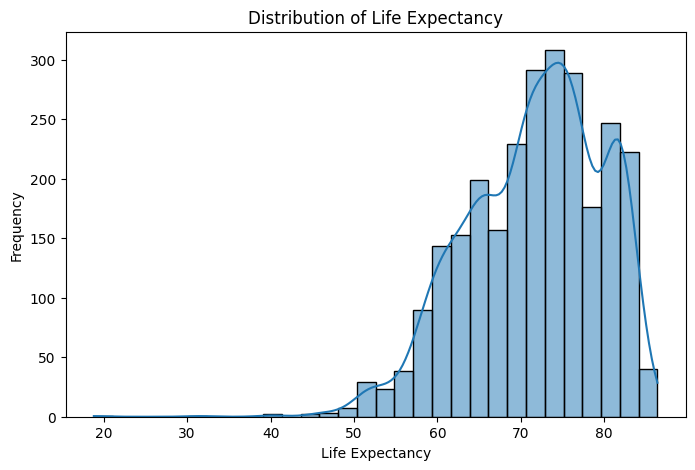

In [27]:
plt.figure(figsize=(8,5))
sns.histplot(df_model["Life_Expectancy"], bins=30, kde=True)
plt.title("Distribution of Life Expectancy")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")
plt.show()

### Conclusion:
Most countries have life expectancy between 60 and 80 years.

## Question 2: Is GDP related to life expectancy?


 
### Hypothesis:
Higher GDP leads to higher life expectancy.

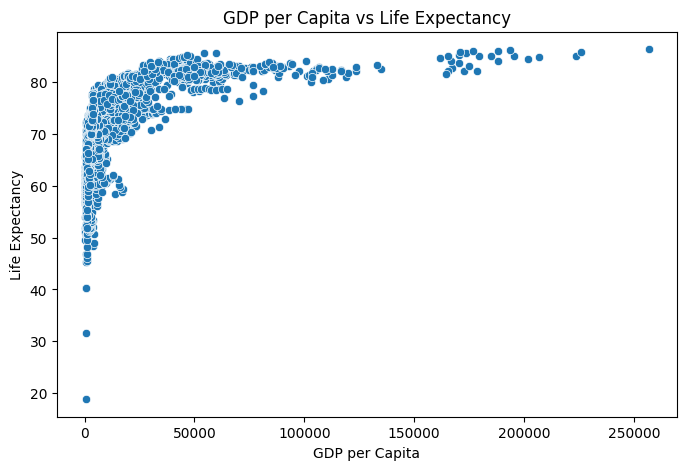

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_model, x="GDP", y="Life_Expectancy")
plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per Capita")
plt.ylabel("Life Expectancy")
plt.show()

### Conclusion:
There is a strong positive relationship between GDP and life expectancy.

## Question 3: Does healthcare spending influence life expectancy?


 
### Hypothesis:
Higher healthcare spending increases life expectancy.

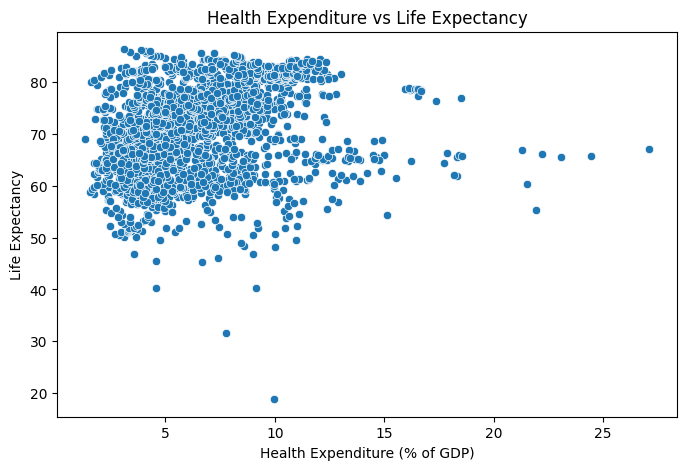

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_model, x="Health_Expenditure", y="Life_Expectancy")
plt.title("Health Expenditure vs Life Expectancy")
plt.xlabel("Health Expenditure (% of GDP)")
plt.ylabel("Life Expectancy")
plt.show()

### Conclusion:
Healthcare expenditure positively impacts life expectancy, but weaker than GDP.

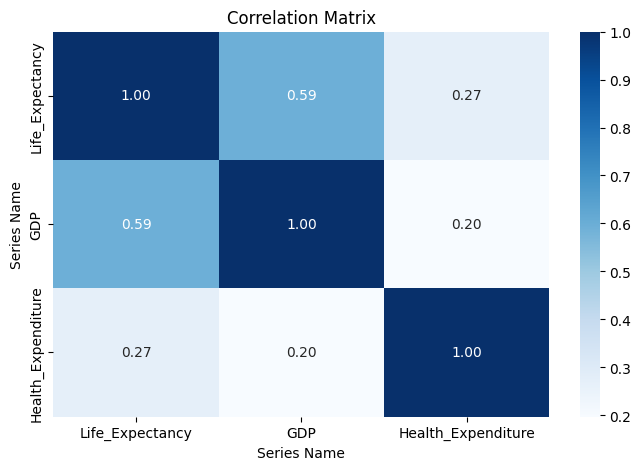

In [30]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df_model[["Life_Expectancy", "GDP", "Health_Expenditure"]].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

### Insight:
 
GDP has a stronger correlation with life expectancy (~0.59) compared to health expenditure (~0.27).

## Modeling

## Question 4: Can economic indicators predict life expectancy?


 
### Hypothesis:
GDP and healthcare spending can predict life expectancy.
 

In [31]:
def evaluate_model(y_test, y_pred):
    """
    Evaluate regression model performance.
 
    Parameters:
    y_test: actual values
    y_pred: predicted values
 
    Returns:
    tuple: R2 score and RMSE
    """
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    return r2, rmse

In [33]:

X = df_model[["GDP", "Health_Expenditure"]]
y = df_model["Life_Expectancy"]
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
 
model = LinearRegression()
model.fit(X_train, y_train)
 
y_pred = model.predict(X_test)

In [34]:
r2, rmse = evaluate_model(y_test, y_pred)
 
print("R² Score:", round(r2, 3))
print("RMSE:", round(rmse, 3))


R² Score: 0.377
RMSE: 6.464


### Conclusion:
The model explains about 38% of variation, meaning other factors also play a role.

## Model Evaluation
 
The model achieved an R² score of approximately 0.38.
 
This indicates that GDP and healthcare expenditure explain part of the variation in life expectancy, but other variables are also important.

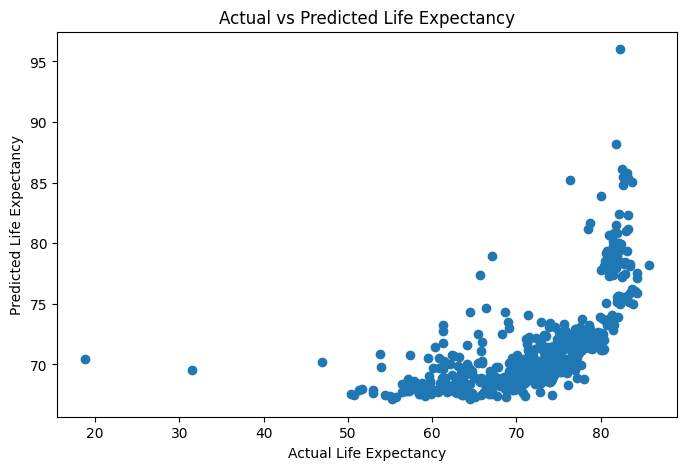

In [35]:

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()

In [35]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)
print("Intercept:", model.intercept_)

              Feature  Coefficient
0                 GDP     0.000166
1  Health_Expenditure     0.436171
Intercept: 66.05373589860213


## Model Interpretation
 
The coefficients indicate that:
 
- GDP has a positive impact on life expectancy
- Health expenditure also contributes positively
 
This suggests that economic strength and healthcare investment are important factors in improving life expectancy.